# Dendrograms Diagrams to support Hierarchical Clustering

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans

In [65]:
#importing the data
df = pd.read_csv("M1 & M4 - Cereals - Cereals (1).csv")
df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,25,3,1.0,0.75,34.384843


## Removing Null Values

In [66]:
#checking how many null values there are
print(df.isnull().sum())

name        0
mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       1
sugars      1
potass      2
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64


In [67]:
#removing null vlaues
df = df.dropna()
print(df.isnull().sum())

name        0
mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       0
sugars      0
potass      0
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64


## Running k-means clustering

In [68]:
X = df.select_dtypes(include='number')


In [69]:
#create kmeans clustering object
kmeans = KMeans(n_clusters=3, random_state=42)

#create new column named cluster where the data prediciton for data X is going to go
df['cluster'] = kmeans.fit_predict(X)

#print dataframe
print(df.head())

                        name mfr type  calories  protein  fat  sodium  fiber  \
0                  100%_Bran   N    C        70        4    1     130   10.0   
1          100%_Natural_Bran   Q    C       120        3    5      15    2.0   
2                   All-Bran   K    C        70        4    1     260    9.0   
3  All-Bran_with_Extra_Fiber   K    C        50        4    0     140   14.0   
5    Apple_Cinnamon_Cheerios   G    C       110        2    2     180    1.5   

   carbo  sugars  potass  vitamins  shelf  weight  cups     rating  cluster  
0    5.0     6.0   280.0        25      3     1.0  0.33  68.402973        1  
1    8.0     8.0   135.0         0      3     1.0  1.00  33.983679        2  
2    7.0     5.0   320.0        25      3     1.0  0.33  59.425505        1  
3    8.0     0.0   330.0        25      3     1.0  0.50  93.704912        1  
5   10.5    10.0    70.0        25      1     1.0  0.75  29.509541        0  


## Apply Hierarchical Clutering to data & Creating the Visualizations

### Complete Linkage Dendrogram

In [70]:
#perform hierarchical clustering
#makes each data point its own cluster and merges it witht he closest cluster while updating distances
Z = linkage(X, method='complete')
print(Z)


[[  5.          22.           1.71293475   2.        ]
 [ 13.          40.           4.24082017   2.        ]
 [ 27.          70.           5.01365502   2.        ]
 [ 24.          41.           8.26133169   2.        ]
 [  4.          17.           9.59987851   2.        ]
 [ 11.          33.          10.54777953   2.        ]
 [ 15.          59.          11.45091957   2.        ]
 [  9.          79.          14.63458133   3.        ]
 [ 43.          44.          14.89967597   2.        ]
 [ 35.          46.          15.32424285   2.        ]
 [ 12.          54.          15.39553368   2.        ]
 [ 30.          39.          16.11181901   2.        ]
 [ 75.          78.          16.9539764    4.        ]
 [ 74.          76.          17.04068651   4.        ]
 [ 14.          80.          17.95888134   3.        ]
 [ 57.          77.          18.58716065   3.        ]
 [  7.          72.          18.60697147   2.        ]
 [ 20.          84.          18.91837143   3.        ]
 [ 61.    

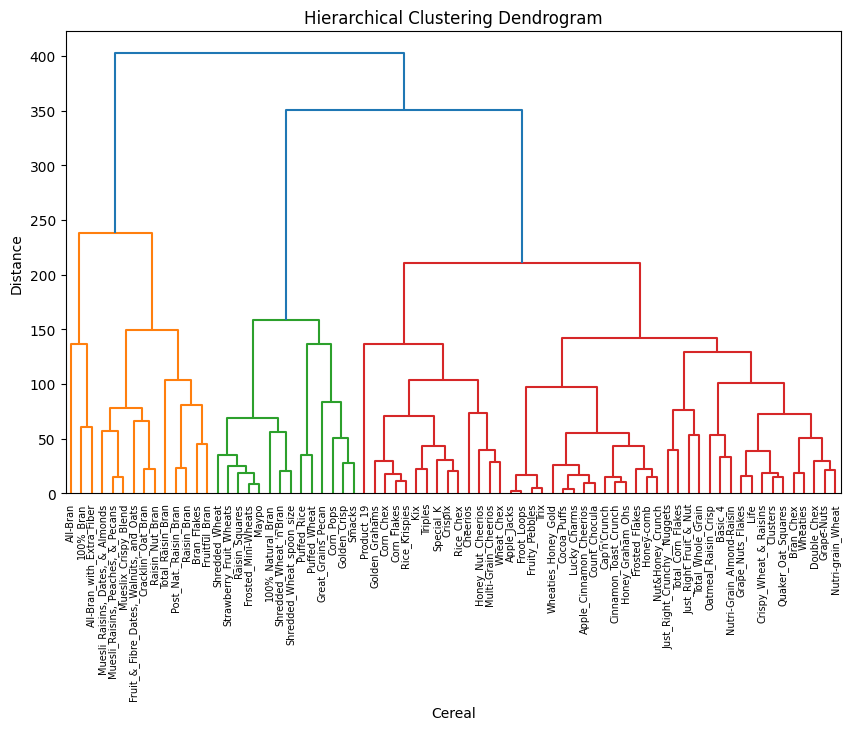

In [71]:
plt.figure(figsize=(10, 6))
#creates the dendrogram and adds the cereal names
dendrogram(Z,labels=df['name'].to_numpy(),
    leaf_rotation=90,
    leaf_font_size=7
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cereal')
plt.ylabel('Distance')
plt.show()


In [72]:
# Assign each row to one of three clusters
df['cluster'] = fcluster(Z, t=3, criterion='maxclust')

# Display the results
print(df.head())

                        name mfr type  calories  protein  fat  sodium  fiber  \
0                  100%_Bran   N    C        70        4    1     130   10.0   
1          100%_Natural_Bran   Q    C       120        3    5      15    2.0   
2                   All-Bran   K    C        70        4    1     260    9.0   
3  All-Bran_with_Extra_Fiber   K    C        50        4    0     140   14.0   
5    Apple_Cinnamon_Cheerios   G    C       110        2    2     180    1.5   

   carbo  sugars  potass  vitamins  shelf  weight  cups     rating  cluster  
0    5.0     6.0   280.0        25      3     1.0  0.33  68.402973        1  
1    8.0     8.0   135.0         0      3     1.0  1.00  33.983679        2  
2    7.0     5.0   320.0        25      3     1.0  0.33  59.425505        1  
3    8.0     0.0   330.0        25      3     1.0  0.50  93.704912        1  
5   10.5    10.0    70.0        25      1     1.0  0.75  29.509541        3  


### Single Linkage Dendrogram

In [73]:
#perform hierarchical clustering
#makes each data point its own cluster and merges it witht he closest cluster while updating distances
Y = linkage(X, method='single')
print(Y)

[[  5.          22.           1.71293475   2.        ]
 [ 13.          40.           4.24082017   2.        ]
 [ 27.          70.           5.01365502   2.        ]
 [ 24.          41.           8.26133169   2.        ]
 [  4.          17.           9.59987851   2.        ]
 [ 75.          78.          10.00577605   4.        ]
 [ 11.          33.          10.54777953   2.        ]
 [  9.          80.          10.8036781    3.        ]
 [ 15.          59.          11.45091957   2.        ]
 [ 74.          76.          12.22906756   4.        ]
 [ 14.          82.          14.16979101   3.        ]
 [ 57.          77.          14.63427955   3.        ]
 [ 43.          44.          14.89967597   2.        ]
 [ 35.          46.          15.32424285   2.        ]
 [ 12.          54.          15.39553368   2.        ]
 [ 30.          39.          16.11181901   2.        ]
 [ 88.          89.          18.11940295   4.        ]
 [ 20.          90.          18.2181999    5.        ]
 [  7.    

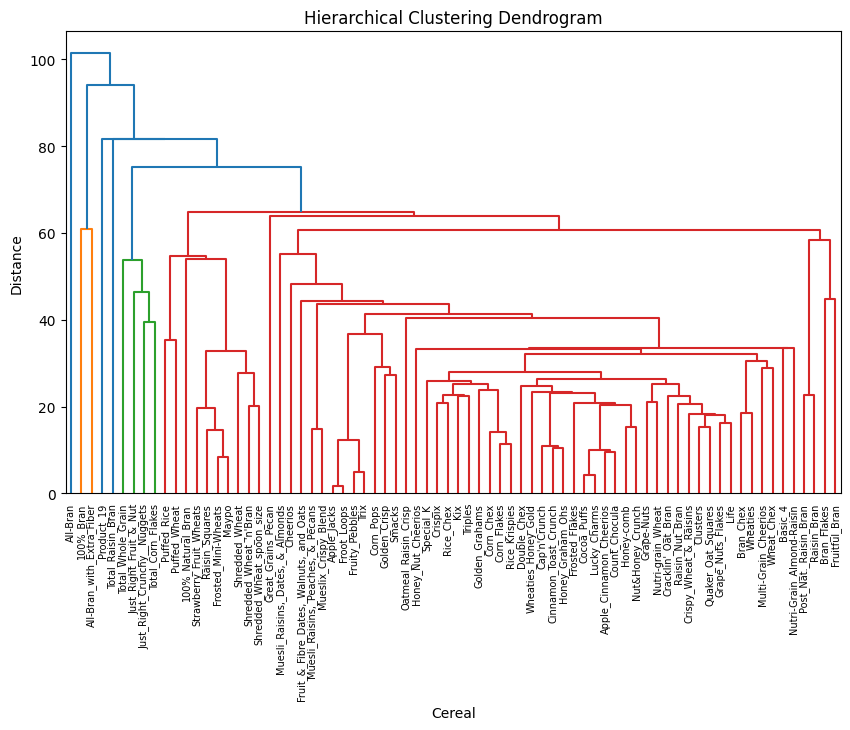

In [74]:
plt.figure(figsize=(10, 6))
#creates the dendrogram and adds the cereal names
dendrogram(Y,labels=df['name'].to_numpy(),
    leaf_rotation=90,
    leaf_font_size=7
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cereal')
plt.ylabel('Distance')
plt.show()

In [75]:
#perform hierarchical clustering
#makes each data point its own cluster and merges it witht he closest cluster while updating distances
Y = linkage(X, method='single')
print(Y)

[[  5.          22.           1.71293475   2.        ]
 [ 13.          40.           4.24082017   2.        ]
 [ 27.          70.           5.01365502   2.        ]
 [ 24.          41.           8.26133169   2.        ]
 [  4.          17.           9.59987851   2.        ]
 [ 75.          78.          10.00577605   4.        ]
 [ 11.          33.          10.54777953   2.        ]
 [  9.          80.          10.8036781    3.        ]
 [ 15.          59.          11.45091957   2.        ]
 [ 74.          76.          12.22906756   4.        ]
 [ 14.          82.          14.16979101   3.        ]
 [ 57.          77.          14.63427955   3.        ]
 [ 43.          44.          14.89967597   2.        ]
 [ 35.          46.          15.32424285   2.        ]
 [ 12.          54.          15.39553368   2.        ]
 [ 30.          39.          16.11181901   2.        ]
 [ 88.          89.          18.11940295   4.        ]
 [ 20.          90.          18.2181999    5.        ]
 [  7.    

## Comparing the dendrogram from a <u>Single Linkage</u> and <u>Complete Linkage</u> Dendrograms

#### For the complete Linkage:
The complete linkage seems to have a lot more mearges for lower distacnes. The complete linkage has a max distance of 400 for its gratest linkage. You can cut this one around the 100 - 150 range. 

#### For the single Linkage:
It seems like the clusters merge where the distances are a lot shorter. Th single linage had a shorter total distance of 100. You can cut this one around teh 40-60 distance range.

